In [1]:

import pandas as pd

from tensorflow.keras.losses import Huber
data_path = "Normalized_WT5.txt"
with open(data_path, "r") as file:
    lines = file.readlines()
# Process the lines
processed_data = []
for line in lines:
    # Remove unnecessary quotes
    cleaned_line = line.replace('"', '').strip().split()
    processed_data.append(cleaned_line)
columns = ["Sequence", "V", "D", "air density", "Humidity", "I", "S_a", "S_b", "y"]
data = pd.DataFrame(processed_data[1:], columns=columns)  # Exclude header from raw data
numeric_columns = ["Sequence", "V", "D", "air density", "Humidity", "I", "S_a", "S_b", "y"]
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")  # Coerce errors into NaN for invalid entries
print(data.head())
print("Dataset shape:", data.shape)


   Sequence         V         D  air density   Humidity         I       S_a  \
0         1  6.873766  174.0575     1.219331  50.082808  0.021919  0.110258   
1         2  7.096613  176.4439     1.219144  48.541693  0.037737  0.061554   
2         3  8.101572  176.3133     1.218397  46.252931  0.049063  0.152517   
3         4  8.762237  181.0317     1.219514  47.099364  0.094166  0.254332   
4         5  9.901171  183.5434     1.216877  44.129409  0.027735  0.073538   

        S_b          y  
0  0.135261  11.653333  
1  0.156136  30.550000  
2  0.223355  43.850000  
3  0.256441  51.660000  
4  0.311642  46.406667  
Dataset shape: (16443, 9)


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
features = ["V", "D", "air density", "Humidity", "I", "S_a", "S_b", "y"]
X = data[features].values

# Define the dimensions and hyperparameters for our autoencoder
input_dim = X.shape[1]
encoding_dim = 4           # bottle neck
hidden_dim = 6             # hidden layer

# encoder
encoder_input = layers.Input(shape=(input_dim,))
hidden_enc = layers.Dense(hidden_dim, activation='relu')(encoder_input)
encoded = layers.Dense(encoding_dim, activation='relu')(hidden_enc)
encoded = layers.Dense(encoding_dim, activation='relu')(hidden_enc)
# decoder
hidden_dec = layers.Dense(hidden_dim, activation='relu')(encoded)
decoder_output = layers.Dense(input_dim, activation='linear')(hidden_dec)

# autoencoder model
autoencoder = models.Model(inputs=encoder_input, outputs=decoder_output)

# autoencoder with MSE loss
autoencoder.compile(optimizer='adam', loss='mse')

# Show model summary
autoencoder.summary()

# Train the autoencoder (adjust epochs, batch_size, etc. as needed)
autoencoder.fit(
    X,
    X,
    epochs=50,
    batch_size=24,
    validation_split=0.2,
    verbose=1
)

# After training, we can get the reconstructed data
reconstructed_X = autoencoder.predict(X)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 6)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │              56 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 168 (672.00 B)

 Trainable params: 168 (672.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5394.2686 - val_loss: 391.2340
Epoch 2/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 280.0392 - val_loss: 131.5039
Epoch 3/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 103.0449 - val_loss: 98.1191
Epoch 4/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 81.7357 - val_loss: 84.0621
Epoch 5/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 72.3669 - val_loss: 79.1354
Epoch 6/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69.3164 - val_loss: 77.3589
Epoch 7/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.8630 - val_loss: 76.5480
Epoch 8/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 66.2402 - val_loss: 75.5865
Epoch 9/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 66.8647 - val_loss: 74.4800
Epoch 10/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 65.0657 - val_loss: 73.4291
Epoch 11/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 64.3900 - val_loss: 71.9681
Epoch 12/50
549/549 ━━━━

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LayerNormalization
import numpy as np

class PositionalEncoding(Layer):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        # Apply sine to even indices in the array; 2i
        sines = np.sin(angle_rads[:, 0::2])

        # Apply cosine to odd indices in the array; 2i + 1
        cosines = np.cos(angle_rads[:, 1::2])

        # Interleave sine and cosine
        pe = np.zeros(angle_rads.shape)
        pe[:, 0::2] = sines
        pe[:, 1::2] = cosines

        # Add a batch dimension
        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]


# Self-Attention (scaled dot-product)
def scaled_dot_product_attention(q, k, v, mask=None):
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, v)
    return output, attention_weights

# Multi-Head Attention layer
class MultiHeadAttention(Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

       # assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.depth = d_model // num_heads
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # scaled dot-product attention
        scaled_attention, _ = scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
        output = self.dense(concat_attention)

        return output


# Transformer Encoder Layer
class TransformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerEncoderLayer, self).__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, mask=None, training=True):
        attn_output = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

In [4]:
# Huber loss definition

import tensorflow.keras.backend as K

def huber_loss(y_true, y_pred, delta=1.0):

    error = y_true - y_pred
    abs_error = K.abs(error)

    is_small_error = K.less(abs_error, delta)
    small_error_loss = 0.5 * K.square(error)
    big_error_loss = delta * abs_error - 0.5 * (delta ** 2)

    return K.mean(tf.where(is_small_error, small_error_loss, big_error_loss), axis=-1)

In [5]:

import random

def slime_mould_algorithm(objective_func, dim, bounds, max_iter=50, population_size=30):
    # generate random position in the search space
    def random_position():
        if isinstance(bounds[0], tuple) or isinstance(bounds[0], list):
            return [random.uniform(bounds[i][0], bounds[i][1]) for i in range(dim)]
        else:
            return [random.uniform(bounds[0], bounds[1]) for _ in range(dim)]

    # population initalization
    population = [random_position() for _ in range(population_size)]
    fitness = [objective_func(ind) for ind in population]

    #the best so far
    best_idx = int(np.argmin(fitness))
    best_sol = population[best_idx]
    best_val = fitness[best_idx]

    for iteration in range(max_iter):
        sorted_indices = np.argsort(fitness)
        population = [population[i] for i in sorted_indices]
        fitness = [fitness[i] for i in sorted_indices]
        if fitness[0] < best_val:
            best_val = fitness[0]
            best_sol = population[0]
        for i in range(population_size):
            p = (1 - (iteration / max_iter))
            if i == 0:
                # The best slime mould moves randomly within small bounds
                population[i] = [
                    val + random.uniform(-p, p) * val for val in population[i]
                ]
            else:
                # Others either converge or diverge from the best
                random_factor = random.uniform(-1, 1)
                population[i] = [
                    best_sol[d] + random_factor * (best_sol[d] - population[i][d])
                    for d in range(dim)
                ]
            if isinstance(bounds[0], tuple) or isinstance(bounds[0], list):
                for d in range(dim):
                    lb, ub = bounds[d]
                    population[i][d] = max(lb, min(ub, population[i][d]))
            else:
                for d in range(dim):
                    population[i][d] = max(bounds[0], min(bounds[1], population[i][d]))
        fitness = [objective_func(ind) for ind in population]

    return best_sol, best_val


#  Suppose we want to optimize a simple sphere function: sum(x^2)
def sphere_function(x):
    return sum([xi**2 for xi in x])

dim = 2
bounds = (-5, 5)
best_solution, best_value = slime_mould_algorithm(
    objective_func=sphere_function,
    dim=dim,
    bounds=bounds,
    max_iter=50,
    population_size=20
)

print("Best solution found (SMA):", best_solution)
print("Objective value:", best_value)


Best solution found (SMA): [-8.207514108238348e-16, 1.300476924418744e-16]
Objective value: 6.905452806787715e-31


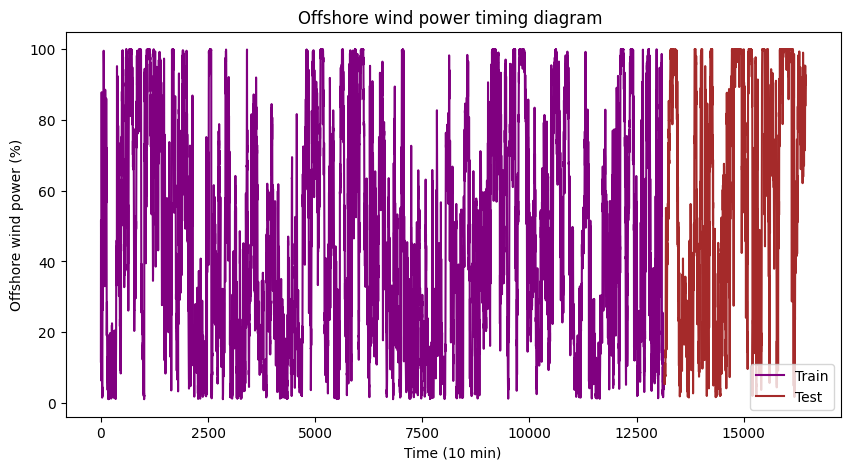

In [6]:
import matplotlib.pyplot as plt

train_size = int(0.8 * len(data))

train_data = data.iloc[:train_size].copy()
test_data  = data.iloc[train_size:].copy()

train_y = train_data["y"].values
test_y  = test_data["y"].values

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_y)), train_y, label='Train', color='purple')
plt.plot(range(len(train_y), len(train_y) + len(test_y)), test_y, label='Test', color='brown')

plt.title("Offshore wind power timing diagram ")
plt.xlabel("Time (10 min)")
plt.ylabel("Offshore wind power (%)")
plt.legend()
plt.show()


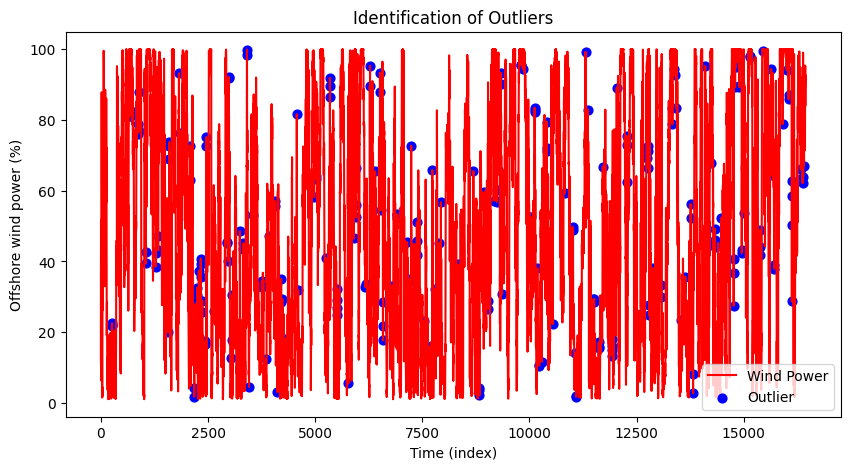

In [7]:

import numpy as np
import matplotlib.pyplot as plt


window_size = 48

# rolling mean and rolling standard deviation over 'y'
rolling_mean = data["y"].rolling(window=window_size, center=True).mean()
rolling_std = data["y"].rolling(window=window_size, center=True).std()

# thresholds for outliers: outside mean ± 2 * std
upper_bound = rolling_mean + 2 * rolling_std
lower_bound = rolling_mean - 2 * rolling_std

outlier_mask = (data["y"] > upper_bound) | (data["y"] < lower_bound)

# Add a new column to mark outliers (True/False)
data["Outlier"] = outlier_mask

x_idx = np.arange(len(data))

plt.figure(figsize=(10, 5))
plt.plot(x_idx, data["y"], label='Wind Power', color='red')

outlier_indices = x_idx[outlier_mask.fillna(False)]
outlier_values  = data["y"][outlier_mask.fillna(False)]
plt.scatter(outlier_indices, outlier_values, color='blue', label='Outlier', s=40)

plt.title("Identification of Outliers")
plt.xlabel("Time (index)")
plt.ylabel("Offshore wind power (%)")
plt.legend()
plt.show()


514/514 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


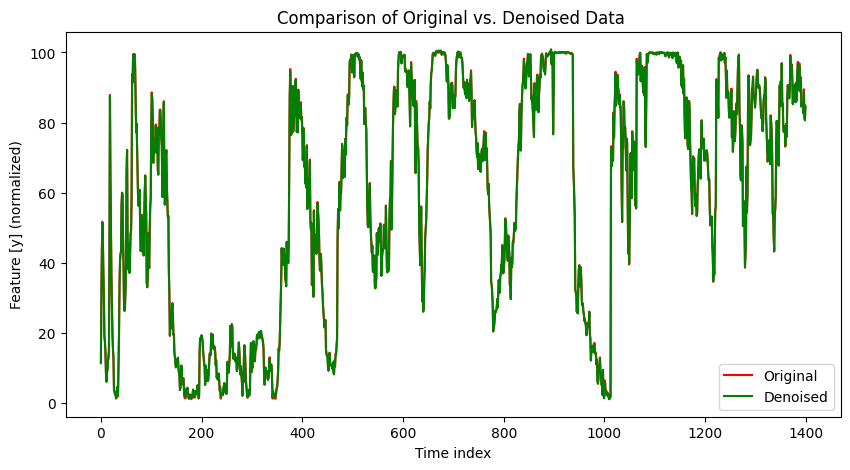

In [10]:

import numpy as np
import matplotlib.pyplot as plt

# We'll obtain the reconstructed denoised data
reconstructed_X = autoencoder.predict(X)
feature_index = 7
original_feature = X[:, feature_index]
denoised_feature = reconstructed_X[:, feature_index]
n_plot = 1400
plt.figure(figsize=(10, 5))
plt.plot(original_feature[:n_plot], label='Original', color='red')
plt.plot(denoised_feature[:n_plot], label='Denoised', color='green')
plt.title("Comparison of Original vs. Denoised Data ")
plt.xlabel("Time index")
plt.ylabel(f"Feature [{features[feature_index]}] (normalized)")
plt.legend()
plt.show()


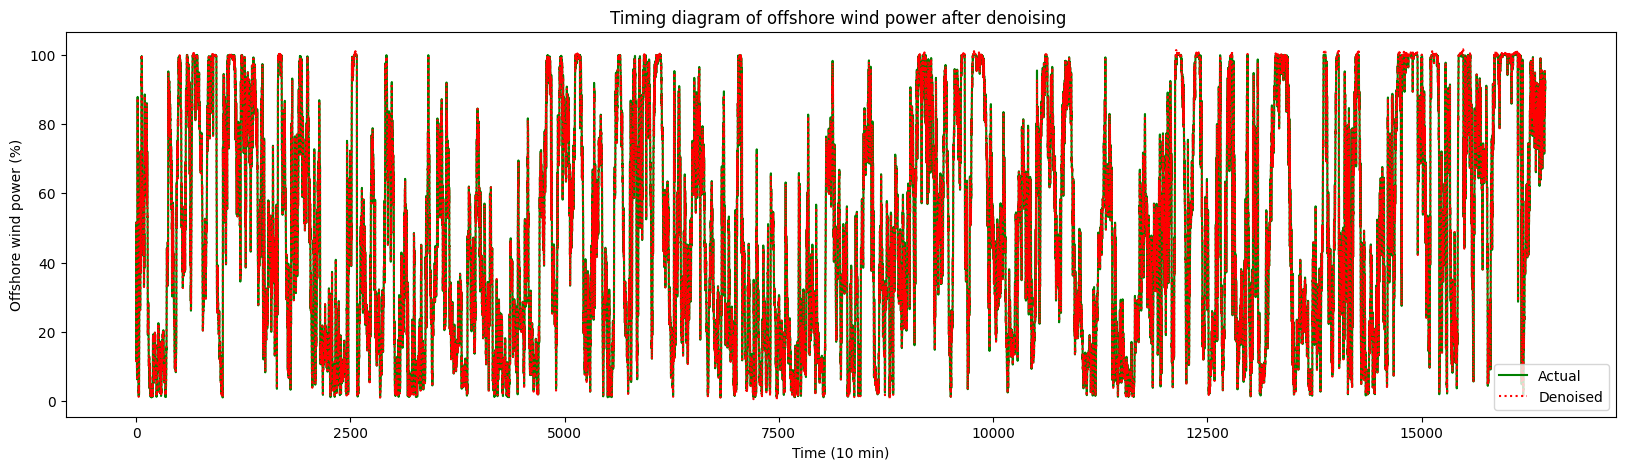

In [11]:
import matplotlib.pyplot as plt

original_y = X[:, -1]
denoised_y = reconstructed_X[:, -1]

plt.figure(figsize=(20, 5))

plt.plot(original_y, color='green', label='Actual')

plt.plot(denoised_y, 'r:', label='Denoised')

plt.title("Timing diagram of offshore wind power after denoising ")
plt.xlabel("Time (10 min)")
plt.ylabel("Offshore wind power (%)")
plt.legend()
plt.show()

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# 1) Split data into training and testing sets BEFORE doing any normalization
train_size = int(0.8 * len(data))
train_data = data.iloc[:train_size].copy()
test_data  = data.iloc[train_size:].copy()

# 2) Separate independent variables (X) and the target variable (y)
feature_cols = ["V", "D", "air density", "Humidity", "I", "S_a", "S_b","y"]
target_col   = "y"

# 4) Fit the scaler ONLY on the training data
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

train_X = scaler_X.fit_transform(train_data[feature_cols])
train_y = scaler_Y.fit_transform(train_data[[target_col]])
test_X  = scaler_X.transform(test_data[feature_cols])
test_y  = scaler_Y.transform(test_data[[target_col]])

# 6) Prepare data for multi-step forecasting via Sliding Window
past_window  = 144
future_steps = 24

def create_sliding_window(X, y, past_size, future_size):
    Xs, Ys = [], []
    for i in range(len(X) - past_size - future_size + 1):
        Xs.append(X[i : i + past_size])
        Ys.append(y[i + past_size : i + past_size + future_size])
    return np.array(Xs), np.array(Ys)

# Create sliding windows for train
X_train_slid, y_train_slid = create_sliding_window(train_X, train_y, past_window, future_steps)

# Create sliding windows for test
X_test_slid, y_test_slid = create_sliding_window(test_X, test_y, past_window, future_steps)


print("X_train_slid shape:", X_train_slid.shape)
print("y_train_slid shape:", y_train_slid.shape)
print("X_test_slid shape:", X_test_slid.shape)
print("y_test_slid shape:", y_test_slid.shape)


X_train_slid shape: (12987, 144, 8)
y_train_slid shape: (12987, 24, 1)
X_test_slid shape: (3122, 144, 8)
y_test_slid shape: (3122, 24, 1)


In [13]:

# Single-Step Data Preparation for 6 Scenarios MLP, RNN, Transformer using MSE, Huber loss functions

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def create_single_step(X, y, past_size=144):

    X_out, y_out = [], []
    num_samples = len(X)
    for i in range(num_samples - past_size):
        X_out.append(X[i : i + past_size])
        y_out.append(y[i + past_size])
    return np.array(X_out), np.array(y_out)

past_window = 144
X_train_single, y_train_single = create_single_step(train_X, train_y, past_window)
X_test_single,  y_test_single  = create_single_step(test_X,  test_y,  past_window)

print("Single-step shapes:")
print("X_train_single:", X_train_single.shape, "y_train_single:", y_train_single.shape)
print("X_test_single: ", X_test_single.shape,  "y_test_single: ", y_test_single.shape)

predictions_dict = {}


Single-step shapes:
X_train_single: (13010, 144, 7) y_train_single: (13010, 1)
X_test_single:  (3145, 144, 7) y_test_single:  (3145, 1)


In [52]:
# 1) MLP + MSE


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

mlp_mse = Sequential([
    Flatten(input_shape=(X_train_single.shape[1], X_train_single.shape[2])),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

mlp_mse.compile(optimizer='adam', loss='mse')  # MSE loss
mlp_mse.fit(
    X_train_single,
    y_train_single,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_mlp_mse = mlp_mse.predict(X_test_single)
predictions_dict["MLP+MSE"] = y_pred_mlp_mse


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0768 - val_loss: 0.0228
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0144 - val_loss: 0.0170
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0122 - val_loss: 0.0138
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0101 - val_loss: 0.0129
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0091 - val_loss: 0.0129
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [50]:
mlp_mse.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 1008)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │          64,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 200,069 (781.52 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 133,380 (521.02 KB)

In [53]:
# 2) MLP + Huber
mlp_huber = Sequential([
    Flatten(input_shape=(X_train_single.shape[1], X_train_single.shape[2])),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

mlp_huber.compile(
    optimizer='adam',
    loss=Huber(delta=1.0)
)
mlp_huber.fit(
    X_train_single,
    y_train_single,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_mlp_huber = mlp_huber.predict(X_test_single)
predictions_dict["MLP+Huber"] = y_pred_mlp_huber


Epoch 1/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0314 - val_loss: 0.0113
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0073 - val_loss: 0.0079
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - val_loss: 0.0081
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0052 - val_loss: 0.0083
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 0.0076
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [40]:
# 3) RNN + MSE
# We can use a simple LSTM or GRU for the RNN approach. We'll do an LSTM here.

from tensorflow.keras.layers import LSTM

rnn_mse = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(X_train_single.shape[1], X_train_single.shape[2])),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

rnn_mse.compile(optimizer='adam', loss='mse')
rnn_mse.fit(
    X_train_single,
    y_train_single,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_rnn_mse = rnn_mse.predict(X_test_single)
predictions_dict["RNN+MSE"] = y_pred_rnn_mse


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0451 - val_loss: 0.0154
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0086 - val_loss: 0.0115
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0075 - val_loss: 0.0112
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0072 - val_loss: 0.0099
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0073 - val_loss: 0.0096
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [51]:
rnn_mse.summary()


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_100 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_101 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_102 (Dense)                    │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,117 (289.52 KB)

 Trainable params: 24,705 (96.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 49,412 (193.02 KB)

In [42]:
# 4) RNN + Huber
rnn_huber = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(X_train_single.shape[1], X_train_single.shape[2])),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

rnn_huber.compile(optimizer='adam', loss=Huber(delta=1.0))
rnn_huber.fit(
    X_train_single,
    y_train_single,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_rnn_huber = rnn_huber.predict(X_test_single)
predictions_dict["RNN+Huber"] = y_pred_rnn_huber


Epoch 1/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0201 - val_loss: 0.0066
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0041 - val_loss: 0.0053
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0039 - val_loss: 0.0063
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0036 - val_loss: 0.0047
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036 - val_loss: 0.0056
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [43]:
# 5) Transformer + MSE

from tensorflow.keras.layers import Input, LayerNormalization, Dropout
from tensorflow.keras.models import Model
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1   = tf.keras.layers.Dropout(rate)
        self.dropout2   = tf.keras.layers.Dropout(rate)

    def call(self, x, training=False):
        attn_output = self.mha(query=x, value=x, key=x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

def build_transformer_model(input_shape, d_model=64, num_heads=2, dff=128, rate=0.1):
    inputs = Input(shape=input_shape)
    x = tf.keras.layers.Dense(d_model)(inputs)

    # Single encoder layer
    x = TransformerEncoder(d_model, num_heads, dff, rate)(x)

    # Global average pool or flatten
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Final dense for single-step output
    outputs = tf.keras.layers.Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

transformer_mse = build_transformer_model(
    input_shape=(X_train_single.shape[1], X_train_single.shape[2]),
    d_model=64,
    num_heads=2,
    dff=128,
    rate=0.1
)

transformer_mse.compile(optimizer='adam', loss='mse')
transformer_mse.fit(
    X_train_single,
    y_train_single,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_transformer_mse = transformer_mse.predict(X_test_single)
predictions_dict["Transformer+MSE"] = y_pred_transformer_mse






Epoch 1/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.1432 - val_loss: 0.1194
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0648 - val_loss: 0.1080
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0649 - val_loss: 0.1375
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0578 - val_loss: 0.1102
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0537 - val_loss: 0.1290
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [47]:

# 6) Transformer + Huber
transformer_huber = build_transformer_model(
    input_shape=(X_train_single.shape[1], X_train_single.shape[2]),
    d_model=64,
    num_heads=2,
    dff=128,
    rate=0.1
)

transformer_huber.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=1.0))
transformer_huber.fit(
    X_train_single,
    y_train_single,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_transformer_huber = transformer_huber.predict(X_test_single)
predictions_dict["Transformer+Huber"] = y_pred_transformer_huber



Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.1154 - val_loss: 0.0509
Epoch 2/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0333 - val_loss: 0.0532
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0323 - val_loss: 0.0497
Epoch 4/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0294 - val_loss: 0.0554
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0270 - val_loss: 0.0490
Epoch 6/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0260 - val_loss: 0.0518
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0232 - val_loss: 0.0516
Epoch 8/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0218 - val_loss: 0.0443
Epoch 9/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0190 - val_loss: 0.0515
Epoch 10/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0172 - val_loss: 0.0509
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [54]:
import math
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):

    epsilon = 1e-7
    y_true = np.maximum(y_true, epsilon)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 1) Scale back the test labels (y_test_single)

y_test_single_reshaped = y_test_single.reshape(-1, 1)
y_test_single_unscaled = scaler_Y.inverse_transform(y_test_single_reshaped).flatten()

# 2) For each model, scale back the predictions and compute MAE, MAPE, RMSE, R^2
for model_name, preds_scaled in predictions_dict.items():
    preds_scaled_2d = preds_scaled.reshape(-1, 1)
    preds_unscaled_2d = scaler_Y.inverse_transform(preds_scaled_2d)
    preds_unscaled = preds_unscaled_2d.flatten()

    mae  = mean_absolute_error(y_test_single_unscaled, preds_unscaled)
    mse  = mean_squared_error(y_test_single_unscaled, preds_unscaled)
    rmse = math.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_single_unscaled, preds_unscaled)/len(preds_unscaled)
    r2   = r2_score(y_test_single_unscaled, preds_unscaled)

    print(f"--- {model_name} ---")
    print(f"MAE:   {mae:.4f}")
    print(f"MAPE:  {mape:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R^2:   {r2:.4f}")
    print("-------------------")


--- MLP+MSE ---
MAE:   10.5624
MAPE:  0.0110
RMSE:  14.2565
R^2:   0.8215
-------------------
--- MLP+Huber ---
MAE:   9.8203
MAPE:  0.0098
RMSE:  13.8823
R^2:   0.8308
-------------------
--- RNN+MSE ---
MAE:   6.9006
MAPE:  0.0082
RMSE:  10.6699
R^2:   0.9000
-------------------
--- RNN+Huber ---
MAE:   7.0883
MAPE:  0.0084
RMSE:  10.6225
R^2:   0.9009
-------------------
--- Transformer+MSE ---
MAE:   26.9013
MAPE:  0.0350
RMSE:  31.4806
R^2:   0.1298
-------------------
--- Transformer+Huber ---
MAE:   25.8584
MAPE:  0.0406
RMSE:  31.3108
R^2:   0.1392
-------------------


In [55]:
import math
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Scale back the test labels to original domain
y_test_unscaled = scaler_Y.inverse_transform(y_test_single).flatten()

# 2) Define MAPE in the original domain
def mean_absolute_percentage_error(y_true, y_pred):
    epsilon = 1e-7
    y_true = np.maximum(y_true, epsilon)
    return (np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

# Models to evaluate
models = [
    "MLP+MSE", "MLP+Huber",
    "RNN+MSE", "RNN+Huber",
    "Transformer+MSE", "Transformer+Huber"
]

# Dictionary to store results
results = {}

# 3) For each model, scale back predictions and compute metrics in original domain
for model_name in models:
    # preds is scaled => shape (N,1) or (N,)
    preds_scaled = predictions_dict[model_name]

    # Reshape to (N,1) for inverse_transform
    preds_scaled_2d = preds_scaled.reshape(-1, 1)

    # Inverse transform
    preds_unscaled_2d = scaler_Y.inverse_transform(preds_scaled_2d)
    preds_unscaled = preds_unscaled_2d.flatten()

    # Compute metrics in original domain
    mae  = mean_absolute_error(y_test_unscaled, preds_unscaled)
    mse  = mean_squared_error(y_test_unscaled, preds_unscaled)
    rmse = math.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_unscaled, preds_unscaled)/len(preds_unscaled)
    r2   = r2_score(y_test_unscaled, preds_unscaled)

    # Store the results
    results[model_name] = {
        "MAE":  mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R2":   r2
    }

# 4) Build table for MSE, Huber columns
def parse_model_name(model_key):
    arch, loss = model_key.split("+")
    return arch, loss

table_rows = []
metrics_order = ["MAE", "MAPE", "RMSE", "R2"]
architectures = ["MLP", "RNN", "Transformer"]

for metric in metrics_order:
    for arch in architectures:
        row = {
            "Index": metric,
            "Model": arch,
            "MSE":   None,
            "Huber": None
        }
        mse_key   = arch + "+MSE"
        huber_key = arch + "+Huber"

        if mse_key in results:
            row["MSE"] = f"{results[mse_key][metric]:.6f}"
        if huber_key in results:
            row["Huber"] = f"{results[huber_key][metric]:.6f}"

        table_rows.append(row)

df_table = pd.DataFrame(table_rows, columns=["Index","Model","MSE","Huber"])

print("Table: Comparison of evaluation indicators for single-step prediction (unscaled domain)")
print(df_table.to_string(index=False))


Table: Comparison of evaluation indicators for single-step prediction (unscaled domain)
Index       Model       MSE     Huber
  MAE         MLP 10.562406  9.820316
  MAE         RNN  6.900592  7.088310
  MAE Transformer 26.901270 25.858402
 MAPE         MLP  0.011022  0.009791
 MAPE         RNN  0.008158  0.008397
 MAPE Transformer  0.034985  0.040588
 RMSE         MLP 14.256497 13.882301
 RMSE         RNN 10.669904 10.622503
 RMSE Transformer 31.480554 31.310792
   R2         MLP  0.821534  0.830779
   R2         RNN  0.900034  0.900920
   R2 Transformer  0.129808  0.139168


In [56]:
import numpy as np
import tensorflow as tf
import math
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout, GlobalAveragePooling1D
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Same TransformerEncoder
class TransformerEncoder(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1   = Dropout(rate)
        self.dropout2   = Dropout(rate)

    def call(self, x, training=False):
        attn_output = self.mha(query=x, value=x, key=x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

def build_transformer_model(
    input_shape,
    horizon=1,
    d_model=64,
    num_heads=2,
    dff=128,
    rate=0.1
):
    inputs = Input(shape=input_shape)
    x = Dense(d_model)(inputs)
    x = TransformerEncoder(d_model, num_heads, dff, rate)(x)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(horizon)(x)  # Model outputs shape (batch, horizon)
    model = Model(inputs=inputs, outputs=outputs)
    return model

def mean_absolute_percentage_error(y_true, y_pred):
    epsilon = 1e-7
    y_true = np.maximum(y_true, epsilon)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100/len(y_pred)

def create_multi_step_data(X, y, past_size=144, future_size=1):
    X_out, y_out = [], []

    if len(y.shape) > 1 and y.shape[1] == 1:
        y = y.ravel()  # flatten

    num_samples = len(X)
    for i in range(num_samples - past_size - future_size + 1):
        X_out.append(X[i : i + past_size])
        y_out.append(y[i + past_size : i + past_size + future_size])

    return np.array(X_out), np.array(y_out)

horizons = [1, 4, 8, 12, 16, 24]
past_window = 144

d_model    = 64
num_heads  = 2
dff        = 128
drop_rate  = 0.1
epochs     = 5
batch_size = 32

all_results = {}

for horizon in horizons:
    # Create multi-step data
    X_train_ms, y_train_ms = create_multi_step_data(
        train_X, train_y,
        past_size=past_window,
        future_size=horizon
    )
    X_test_ms, y_test_ms   = create_multi_step_data(
        test_X,  test_y,
        past_size=past_window,
        future_size=horizon
    )

    print(f"\n=== Horizon t+{horizon} ===")
    print("X_train_ms shape:", X_train_ms.shape, "y_train_ms shape:", y_train_ms.shape)
    print("X_test_ms shape: ", X_test_ms.shape,  "y_test_ms shape: ", y_test_ms.shape)

    if X_train_ms.shape[0] == 0 or X_test_ms.shape[0] == 0:
        print(f"Skipping horizon t+{horizon} due to insufficient data.")
        continue

    # Build two models: Transformer + MSE, Transformer + Huber
    input_shape = (past_window, train_X.shape[1])

    # (A) Transformer + MSE
    model_mse = build_transformer_model(
        input_shape=input_shape,
        horizon=horizon,
        d_model=d_model,
        num_heads=num_heads,
        dff=dff,
        rate=drop_rate
    )
    model_mse.compile(optimizer='adam', loss='mse')

    # (B) Transformer + Huber
    model_huber = build_transformer_model(
        input_shape=input_shape,
        horizon=horizon,
        d_model=d_model,
        num_heads=num_heads,
        dff=dff,
        rate=drop_rate
    )
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model_huber.compile(optimizer='adam', loss=huber_loss)

    # Train
    model_mse.fit(X_train_ms, y_train_ms, epochs=epochs, batch_size=batch_size, verbose=1)
    model_huber.fit(X_train_ms, y_train_ms, epochs=epochs, batch_size=batch_size, verbose=1)

    # Predict in scaled domain
    y_pred_mse   = model_mse.predict(X_test_ms)
    y_pred_huber = model_huber.predict(X_test_ms)
    # Scale back
    y_test_2d      = y_test_ms.reshape(-1, 1)
    y_test_unscaled_2d = scaler_Y.inverse_transform(y_test_2d)
    y_test_unscaled    = y_test_unscaled_2d.flatten()  # shape (N*horizon,)

    # MSE model
    mse_2d   = y_pred_mse.reshape(-1, 1)
    mse_unsc = scaler_Y.inverse_transform(mse_2d).flatten()

    # Huber model
    huber_2d  = y_pred_huber.reshape(-1, 1)
    huber_unsc= scaler_Y.inverse_transform(huber_2d).flatten()

    # Flatten for metrics
    def get_metrics(y_true, y_pred):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred)
        return mae, mape, rmse

    mae_mse, mape_mse, rmse_mse     = get_metrics(y_test_unscaled, mse_unsc)
    mae_huber, mape_huber, rmse_hu = get_metrics(y_test_unscaled, huber_unsc)

    print(f"MSE => MAE={mae_mse:.4f}, MAPE={mape_mse:.4f}, RMSE={rmse_mse:.4f}")
    print(f"Huber => MAE={mae_huber:.4f}, MAPE={mape_huber:.4f}, RMSE={rmse_hu:.4f}")

    # Store final results
    all_results[horizon] = {
        "MSE":   (mae_mse, mape_mse, rmse_mse),
        "Huber": (mae_huber, mape_huber, rmse_hu)
    }



=== Horizon t+1 ===
X_train_ms shape: (13010, 144, 8) y_train_ms shape: (13010, 1)
X_test_ms shape:  (3145, 144, 8) y_test_ms shape:  (3145, 1)
Epoch 1/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.1810
Epoch 2/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0717
Epoch 3/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0666
Epoch 4/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0621
Epoch 5/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0580
Epoch 1/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0769
Epoch 2/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0363
Epoch 3/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0348
Epoch 4/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0320
Epoch 5/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0307
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MSE => MAE=24.1854, MAPE=0.0375, RMSE=29.6409
Huber => MAE=30.1404, MAPE=0.0536, RMSE=39.7956

=== Horizon t+4 =

In [57]:


def create_multi_step_data(X, y, past_size=144, future_size=1):
    X_out, y_out = [], []

    if len(y.shape) > 1 and y.shape[1] == 1:
        y = y.ravel()

    num_samples = len(X)
    for i in range(num_samples - past_size - future_size + 1):
        X_out.append(X[i : i + past_size])
        y_out.append(y[i + past_size : i + past_size + future_size])

    return np.array(X_out), np.array(y_out)


In [58]:


import pandas as pd

table_rows = []

for horizon in sorted(all_results.keys()):
    (mae_mse, mape_mse, rmse_mse)     = all_results[horizon]["MSE"]
    (mae_hu,  mape_hu,  rmse_hu)      = all_results[horizon]["Huber"]

    table_rows.append({
        "Time index": f"t+{horizon}",
        "Metric": "MAE",
        "Transformer(MSE)":   mae_mse,
        "Transformer(Huber)": mae_hu
    })
    table_rows.append({
        "Time index": f"t+{horizon}",
        "Metric": "MAPE",
        "Transformer(MSE)":   mape_mse,
        "Transformer(Huber)": mape_hu
    })
    table_rows.append({
        "Time index": f"t+{horizon}",
        "Metric": "RMSE",
        "Transformer(MSE)":   rmse_mse,
        "Transformer(Huber)": rmse_hu
    })

df_multi = pd.DataFrame(
    table_rows,
    columns=["Time index","Metric","Transformer(MSE)","Transformer(Huber)"]
)

def fmt(x):
    if isinstance(x, float):
        return f"{x:.4f}"
    return x

df_multi_formatted = df_multi.applymap(fmt)

print("\nTable: Multi-step prediction comparison (Transformer only)\n")
print(df_multi_formatted.to_string(index=False))




Table: Multi-step prediction comparison (Transformer only)

Time index Metric Transformer(MSE) Transformer(Huber)
       t+1    MAE          24.1854            30.1404
       t+1   MAPE           0.0375             0.0536
       t+1   RMSE          29.6409            39.7956
       t+4    MAE          28.4684            28.9386
       t+4   MAPE           0.0095             0.0081
       t+4   RMSE          33.2122            35.6618
       t+8    MAE          34.6347            25.2773
       t+8   MAPE           0.0054             0.0046
       t+8   RMSE          41.7274            30.8781
      t+12    MAE          32.7241            26.6980
      t+12   MAPE           0.0039             0.0029
      t+12   RMSE          38.8916            31.6310
      t+16    MAE          31.7033            29.4380
      t+16   MAPE           0.0027             0.0022
      t+16   RMSE          36.4002            34.3028
      t+24    MAE          29.9775            30.1381
      t+24   MAPE    

<ipython-input-58-dc9673831f84>:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_multi_formatted = df_multi.applymap(fmt)
